In [2]:
%pip install numpy pandas matplotlib seaborn sqlalchemy python-dotenv cartopy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import dotenv_values
from urllib.parse import quote_plus

In [45]:
# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE flight_date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport, flight_date
"""
mart_daily_flights_weather = pd.read_sql(query, engine)

In [46]:
mart_daily_flights_weather.head(1)

,airport,airport_name,city,country,flight_date,dep_scheduled,dep_not_cancelled,dep_cancelled,dep_diverted,dep_early_flight,...,cancel_rate,divert_rate,dep_delayed_rate,arr_delayed_rate,max_temp_c,min_temp_c,precipitation_mm,avg_wind_direction,avg_wind_speed_kmh,avg_pressure_hpa
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-22,1035,1034,1,1,638,...,0.1,0.1,16.43,12.66,36.1,22.2,0.0,0,12.2,1013.1


In [12]:
mart_daily_flights_weather.columns

Index(['airport', 'airport_name', 'city', 'country', 'flight_date',
       'dep_scheduled', 'dep_not_cancelled', 'dep_cancelled', 'dep_diverted',
       'dep_early_flight', 'dep_on_time_flight', 'dep_delayed_flight',
       'dep_del_1h', 'dep_del_2h', 'dep_del_3h', 'dep_del_4h', 'dep_del_5h',
       'dep_del_6h', 'dep_del_12h', 'dep_del_24h', 'dep_delayed_1day',
       'avg_dep_delay', 'arr_scheduled', 'arr_not_cancelled', 'arr_cancelled',
       'arr_diverted', 'arr_early_flight', 'arr_on_time_flight',
       'arr_delayed_flight', 'arr_del_1h', 'arr_del_2h', 'arr_del_3h',
       'arr_del_4h', 'arr_del_5h', 'arr_del_6h', 'arr_del_12h', 'arr_del_24h',
       'arr_delayed_1day', 'avg_arr_delay', 'total_scheduled',
       'total_cancelled', 'total_diverted', 'total_not_cancelled',
       'cancel_rate', 'divert_rate', 'dep_delayed_rate', 'arr_delayed_rate',
       'max_temp_c', 'min_temp_c', 'precipitation_mm', 'avg_wind_direction',
       'avg_wind_speed_kmh', 'avg_pressure_hpa'],
      d

In [ ]:
# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather ----
query = f"""
SELECT airport_code,
       date,
       avg_wind_speed_kmh,
       precipitation_mm,
       avg_pressure_hpa
FROM {pg_schema}.prep_weather_daily
WHERE airport_code IN ('TPA','TLH','ATL','CLT')
  AND date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport_code, date
"""
df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

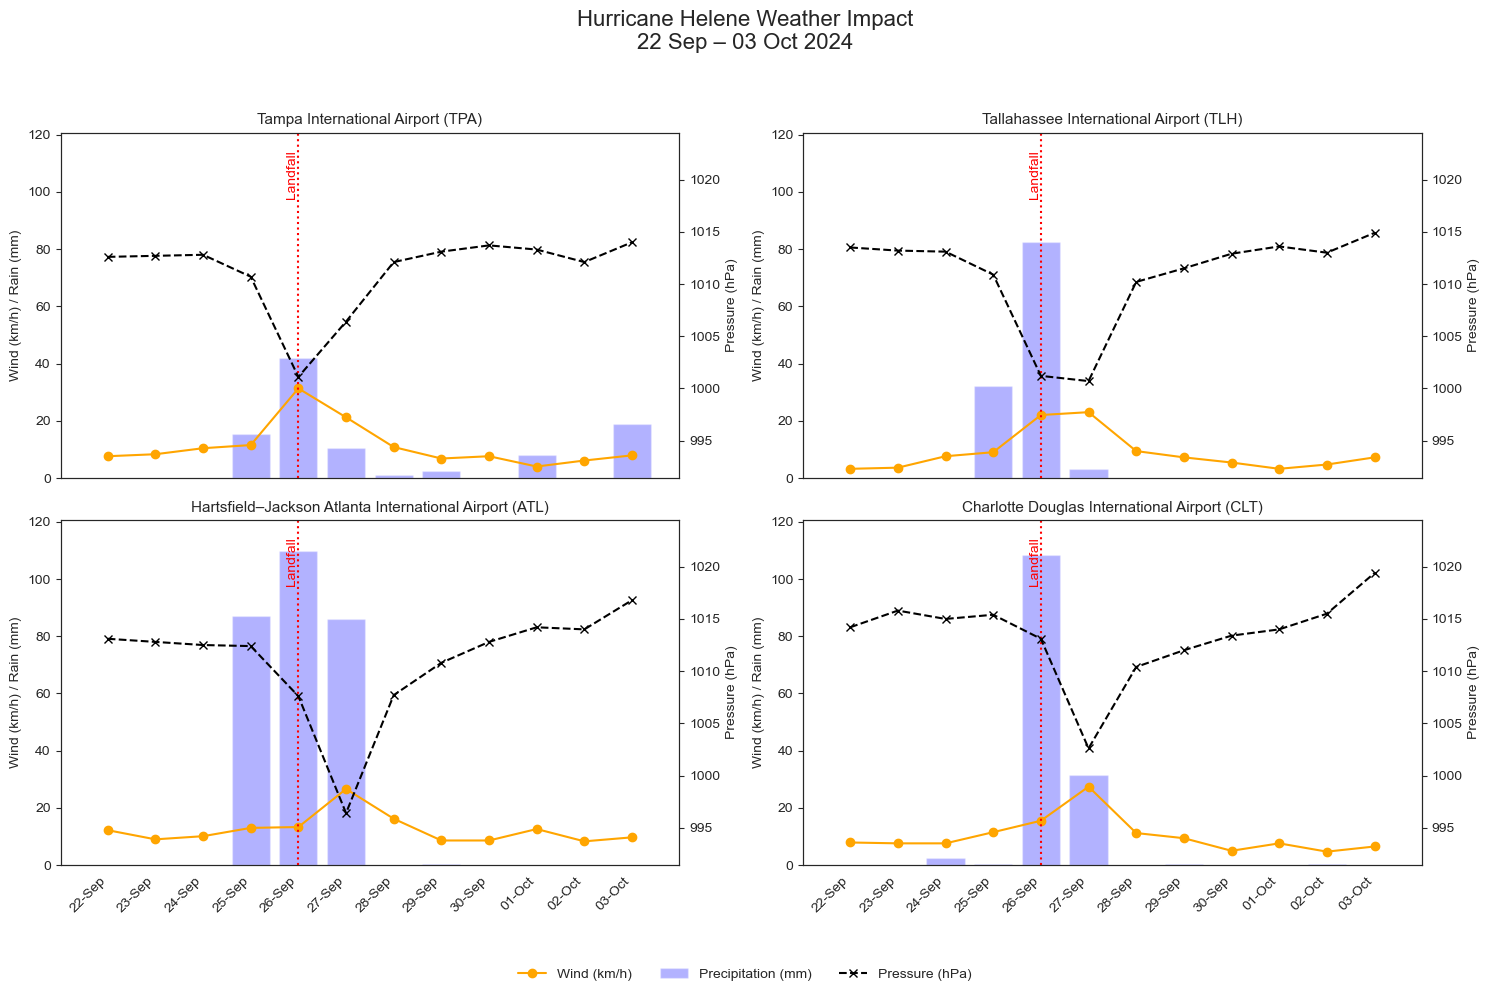

In [33]:
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather ----
query = f"""
SELECT airport_code,
       date,
       avg_wind_speed_kmh,
       precipitation_mm,
       avg_pressure_hpa
FROM {pg_schema}.prep_weather_daily
WHERE airport_code IN ('TPA','TLH','ATL','CLT')
  AND date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport_code, date
"""
df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

import matplotlib.dates as mdates

airport_names = {
    'TPA': 'Tampa International Airport',
    'TLH': 'Tallahassee International Airport',
    'ATL': 'Hartsfield–Jackson Atlanta International Airport',
    'CLT': 'Charlotte Douglas International Airport'
}

airports = ['TPA', 'TLH', 'ATL', 'CLT']
helene_day = pd.to_datetime("2024-09-26")

# ---- Global limits (same scales for all subplots) ----
wind_max = df['avg_wind_speed_kmh'].max()
rain_max = df['precipitation_mm'].max()
pressure_min = df['avg_pressure_hpa'].min()
pressure_max = df['avg_pressure_hpa'].max()

# padding only upwards
left_ymax = max(wind_max, rain_max) * 1.10  # +10% сверху
right_ymin = pressure_min * 0.995          # маленький отступ вниз
right_ymax = pressure_max * 1.005          # маленький отступ вверх

# ---- Plot Settings ----
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

fig.suptitle("Hurricane Helene Weather Impact\n22 Sep – 03 Oct 2024", fontsize=16, y=0.98)

wind_line = None
rain_bar = None
pressure_line = None

for ax, airport in zip(axes, airports):
    sub = df[df['airport_code'] == airport].sort_values('date')

    wind_line, = ax.plot(
        sub['date'], sub['avg_wind_speed_kmh'],
        color='orange', marker='o', label='Wind (km/h)'
    )

    rain_bar = ax.bar(
        sub['date'], sub['precipitation_mm'],
        alpha=0.3, color='blue', label='Precipitation (mm)'
    )

    ax2 = ax.twinx()
    pressure_line, = ax2.plot(
        sub['date'], sub['avg_pressure_hpa'],
        color='black', linestyle='--', marker='x', label='Pressure (hPa)'
    )

    ax.set_title(f"{airport_names.get(airport, airport)} ({airport})", fontsize=11)
    ax.set_ylabel("Wind (km/h) / Rain (mm)")
    ax2.set_ylabel("Pressure (hPa)")

    # ---- FIX: left y starts at 0 (no floating) ----
    ax.set_ylim(0, left_ymax)
    ax2.set_ylim(right_ymin, right_ymax)

    ax.grid(False)
    ax2.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.axvline(helene_day, color='red', linestyle=':', linewidth=1.5)
    
    ax.text(
        helene_day,
        left_ymax * 0.95,
        "Landfall",
        color='red',
        rotation=90,
        verticalalignment='top',
        horizontalalignment='right'
    )

# ---- One common legend ----
handles = [wind_line, rain_bar, pressure_line]
labels = ['Wind (km/h)', 'Precipitation (mm)', 'Pressure (hPa)']
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

plt.savefig("helene_weather_summary_22_sep_till_03_oct_2024.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
mart_daily_flights_weather.columns

Index(['airport', 'airport_name', 'city', 'country', 'flight_date',
       'dep_scheduled', 'dep_not_cancelled', 'dep_cancelled', 'dep_diverted',
       'dep_early_flight', 'dep_on_time_flight', 'dep_delayed_flight',
       'dep_del_1h', 'dep_del_2h', 'dep_del_3h', 'dep_del_4h', 'dep_del_5h',
       'dep_del_6h', 'dep_del_12h', 'dep_del_24h', 'dep_delayed_1day',
       'avg_dep_delay', 'arr_scheduled', 'arr_not_cancelled', 'arr_cancelled',
       'arr_diverted', 'arr_early_flight', 'arr_on_time_flight',
       'arr_delayed_flight', 'arr_del_1h', 'arr_del_2h', 'arr_del_3h',
       'arr_del_4h', 'arr_del_5h', 'arr_del_6h', 'arr_del_12h', 'arr_del_24h',
       'arr_delayed_1day', 'avg_arr_delay', 'total_scheduled',
       'total_cancelled', 'total_diverted', 'total_not_cancelled',
       'cancel_rate', 'divert_rate', 'dep_delayed_rate', 'arr_delayed_rate',
       'max_temp_c', 'min_temp_c', 'precipitation_mm', 'avg_wind_direction',
       'avg_wind_speed_kmh', 'avg_pressure_hpa', 'perc_ca

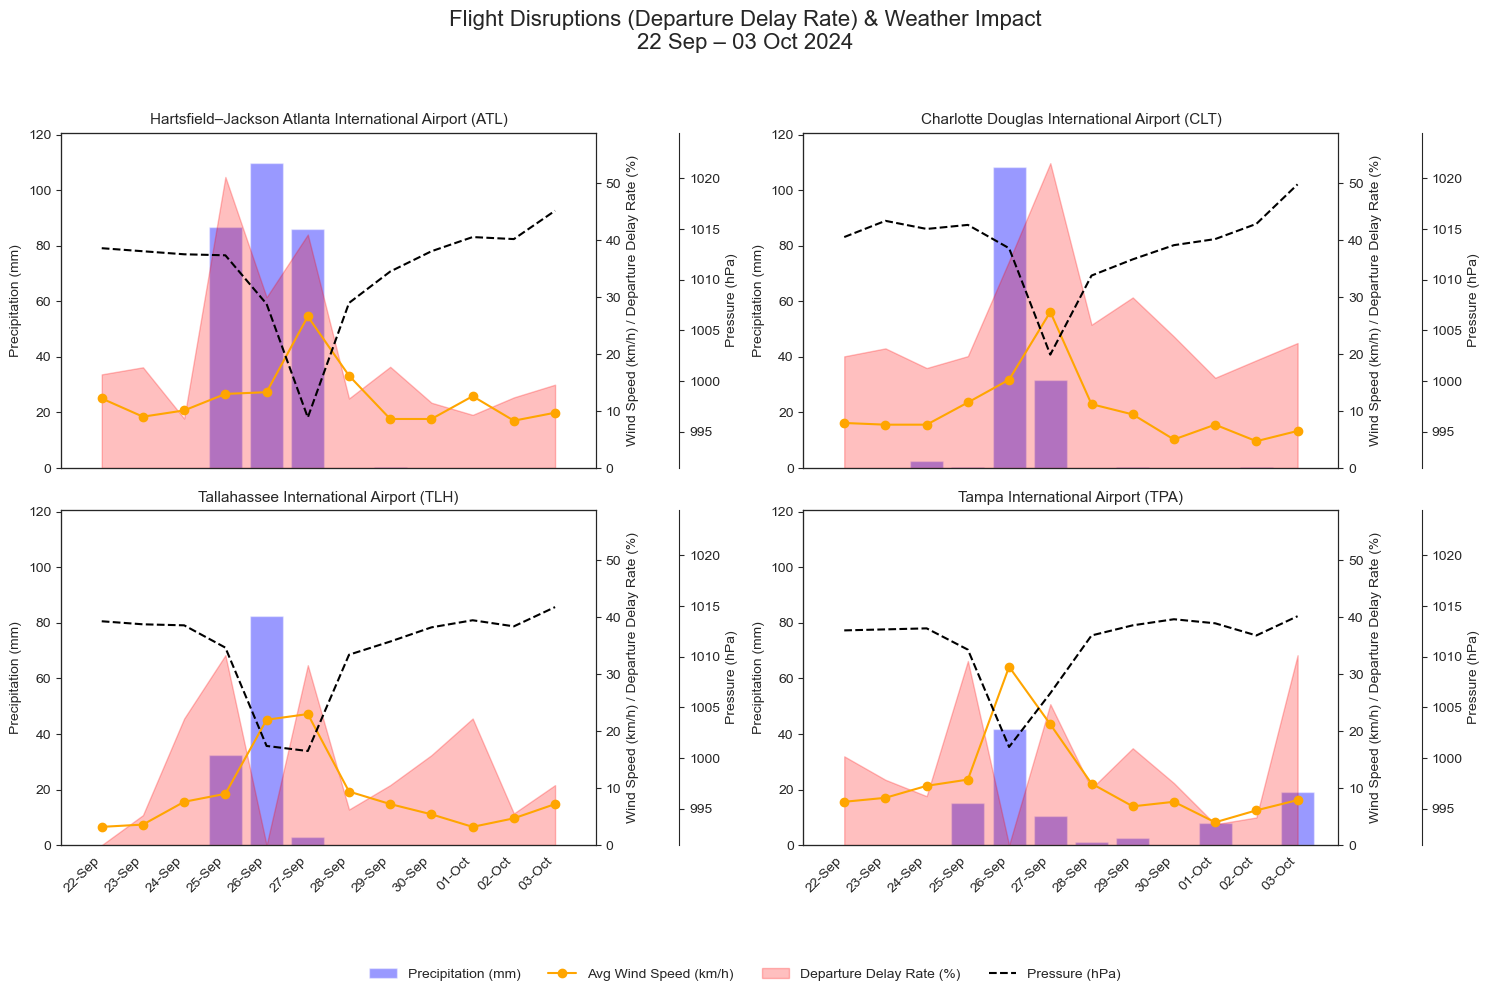

In [34]:
airport_names = {
    'TPA': 'Tampa International Airport',
    'TLH': 'Tallahassee International Airport',
    'ATL': 'Hartsfield–Jackson Atlanta International Airport',
    'CLT': 'Charlotte Douglas International Airport'
}

# если вдруг не datetime
mart_daily_flights_weather['flight_date'] = pd.to_datetime(mart_daily_flights_weather['flight_date'])

airports = mart_daily_flights_weather['airport'].unique()

# --- Global scales ---
delay_max = mart_daily_flights_weather['dep_delayed_rate'].max()
wind_max = mart_daily_flights_weather['avg_wind_speed_kmh'].max()
rain_max = mart_daily_flights_weather['precipitation_mm'].max()
pressure_min = mart_daily_flights_weather['avg_pressure_hpa'].min()
pressure_max = mart_daily_flights_weather['avg_pressure_hpa'].max()

left_ymax = rain_max * 1.1
mid_ymax = max(delay_max, wind_max) * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Flight Disruptions (Departure Delay Rate) & Weather Impact\n22 Sep – 03 Oct 2024",
    fontsize=16,
    y=0.98
)

rain_handle = None
wind_handle = None
delay_handle = None
pressure_handle = None

for ax, airport in zip(axes, airports):
    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    # --- Precipitation (bars, left axis) ---
    rain_handle = ax.bar(
        sub['flight_date'],
        sub['precipitation_mm'],
        alpha=0.4,
        color='blue',
        label="Precipitation (mm)"
    )
    ax.set_ylim(0, left_ymax)
    ax.set_ylabel("Precipitation (mm)")

    # --- Wind + Delay (right axis 1) ---
    ax2 = ax.twinx()

    wind_handle, = ax2.plot(
        sub['flight_date'],
        sub['avg_wind_speed_kmh'],
        color='orange',
        marker='o',
        label="Avg Wind Speed (km/h)"
    )

    # delay as area (not line/bar)
    delay_handle = ax2.fill_between(
        sub['flight_date'],
        sub['dep_delayed_rate'],
        color='red',
        alpha=0.25,
        label="Departure Delay Rate (%)"
    )

    ax2.set_ylim(0, mid_ymax)
    ax2.set_ylabel("Wind Speed (km/h) / Departure Delay Rate (%)")

    # --- Pressure (third axis) ---
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    pressure_handle, = ax3.plot(
        sub['flight_date'],
        sub['avg_pressure_hpa'],
        color='black',
        linestyle='--',
        label="Pressure (hPa)"
    )

    ax3.set_ylim(pressure_min * 0.995, pressure_max * 1.005)
    ax3.set_ylabel("Pressure (hPa)")

    ax.set_title(f"{airport_names.get(airport, airport)} ({airport})", fontsize=11)

    ax.grid(False)
    ax2.grid(False)
    ax3.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- One common legend ---
handles = [rain_handle, wind_handle, delay_handle, pressure_handle]
labels = [
    "Precipitation (mm)",
    "Avg Wind Speed (km/h)",
    "Departure Delay Rate (%)",
    "Pressure (hPa)"
]
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("Departure Delay Rate.png", dpi=300, bbox_inches="tight")
plt.show()

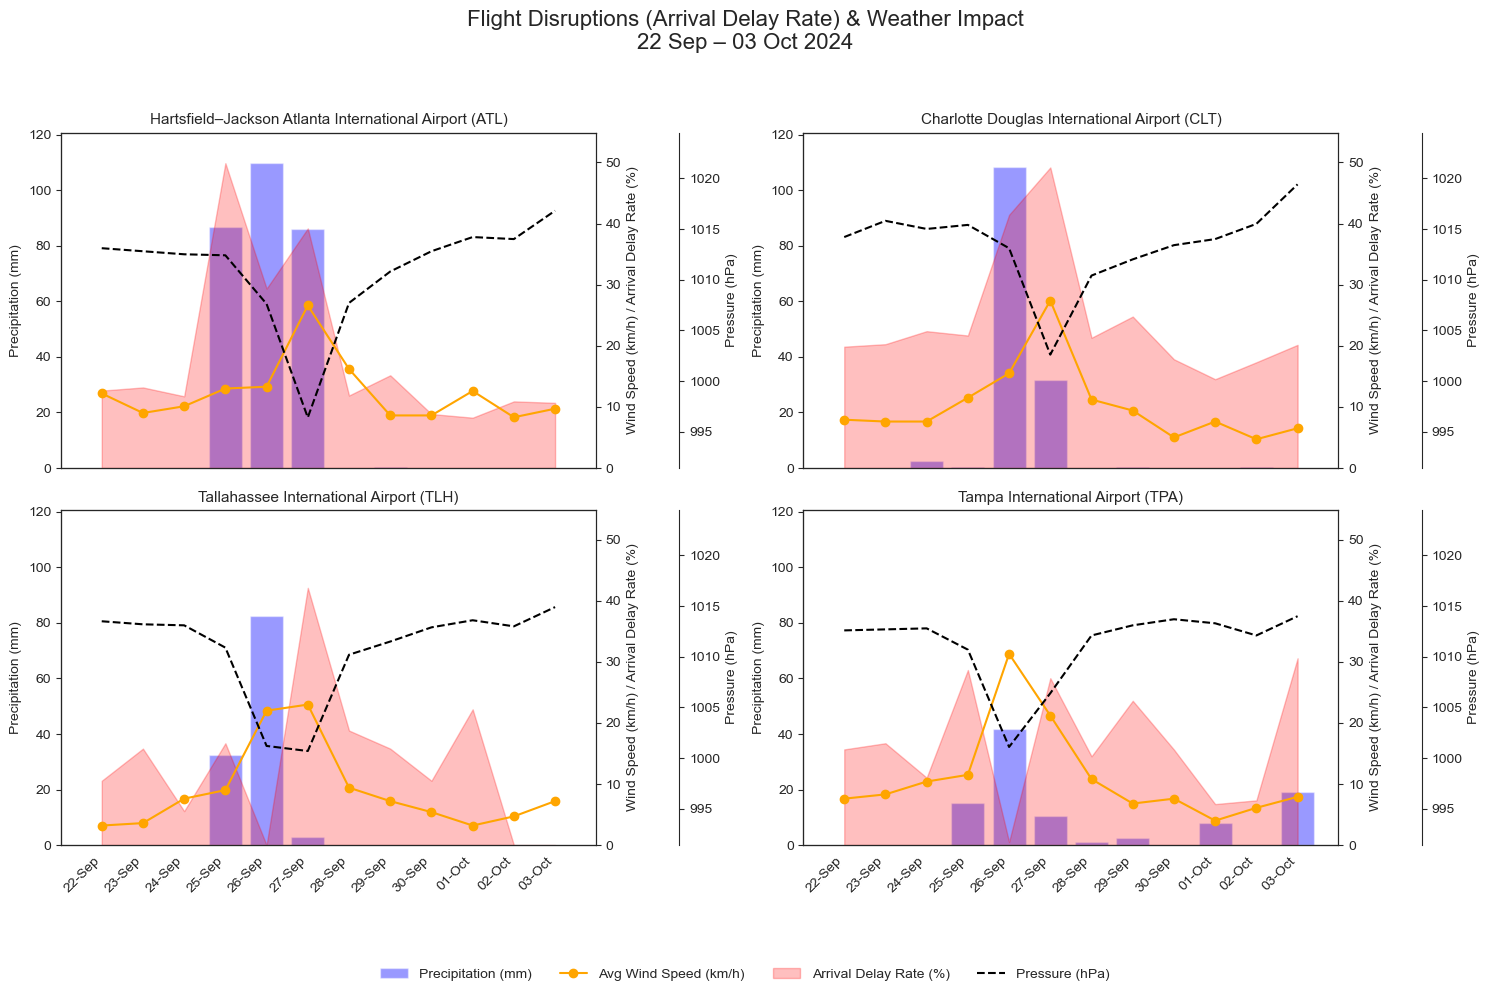

In [35]:
airport_names = {
    'TPA': 'Tampa International Airport',
    'TLH': 'Tallahassee International Airport',
    'ATL': 'Hartsfield–Jackson Atlanta International Airport',
    'CLT': 'Charlotte Douglas International Airport'
}

# если вдруг не datetime
mart_daily_flights_weather['flight_date'] = pd.to_datetime(mart_daily_flights_weather['flight_date'])

airports = mart_daily_flights_weather['airport'].unique()

# --- Global scales ---
delay_max = mart_daily_flights_weather['arr_delayed_rate'].max()
wind_max = mart_daily_flights_weather['avg_wind_speed_kmh'].max()
rain_max = mart_daily_flights_weather['precipitation_mm'].max()
pressure_min = mart_daily_flights_weather['avg_pressure_hpa'].min()
pressure_max = mart_daily_flights_weather['avg_pressure_hpa'].max()

left_ymax = rain_max * 1.1
mid_ymax = max(delay_max, wind_max) * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Flight Disruptions (Arrival Delay Rate) & Weather Impact\n22 Sep – 03 Oct 2024",
    fontsize=16,
    y=0.98
)

rain_handle = None
wind_handle = None
delay_handle = None
pressure_handle = None

for ax, airport in zip(axes, airports):
    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    # --- Precipitation (bars, left axis) ---
    rain_handle = ax.bar(
        sub['flight_date'],
        sub['precipitation_mm'],
        alpha=0.4,
        color='blue',
        label="Precipitation (mm)"
    )
    ax.set_ylim(0, left_ymax)
    ax.set_ylabel("Precipitation (mm)")

    # --- Wind + Delay (right axis 1) ---
    ax2 = ax.twinx()

    wind_handle, = ax2.plot(
        sub['flight_date'],
        sub['avg_wind_speed_kmh'],
        color='orange',
        marker='o',
        label="Avg Wind Speed (km/h)"
    )

    # delay as area (not line/bar)
    delay_handle = ax2.fill_between(
        sub['flight_date'],
        sub['arr_delayed_rate'],
        color='red',
        alpha=0.25,
        label="Arrival Delay Rate (%)"
    )

    ax2.set_ylim(0, mid_ymax)
    ax2.set_ylabel("Wind Speed (km/h) / Arrival Delay Rate (%)")

    # --- Pressure (third axis) ---
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    pressure_handle, = ax3.plot(
        sub['flight_date'],
        sub['avg_pressure_hpa'],
        color='black',
        linestyle='--',
        label="Pressure (hPa)"
    )

    ax3.set_ylim(pressure_min * 0.995, pressure_max * 1.005)
    ax3.set_ylabel("Pressure (hPa)")

    ax.set_title(f"{airport_names.get(airport, airport)} ({airport})", fontsize=11)

    ax.grid(False)
    ax2.grid(False)
    ax3.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- One common legend ---
handles = [rain_handle, wind_handle, delay_handle, pressure_handle]
labels = [
    "Precipitation (mm)",
    "Avg Wind Speed (km/h)",
    "Arrival Delay Rate (%)",
    "Pressure (hPa)"
]
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("Arrival_Delay_Rate.png", dpi=300, bbox_inches="tight")
plt.show()

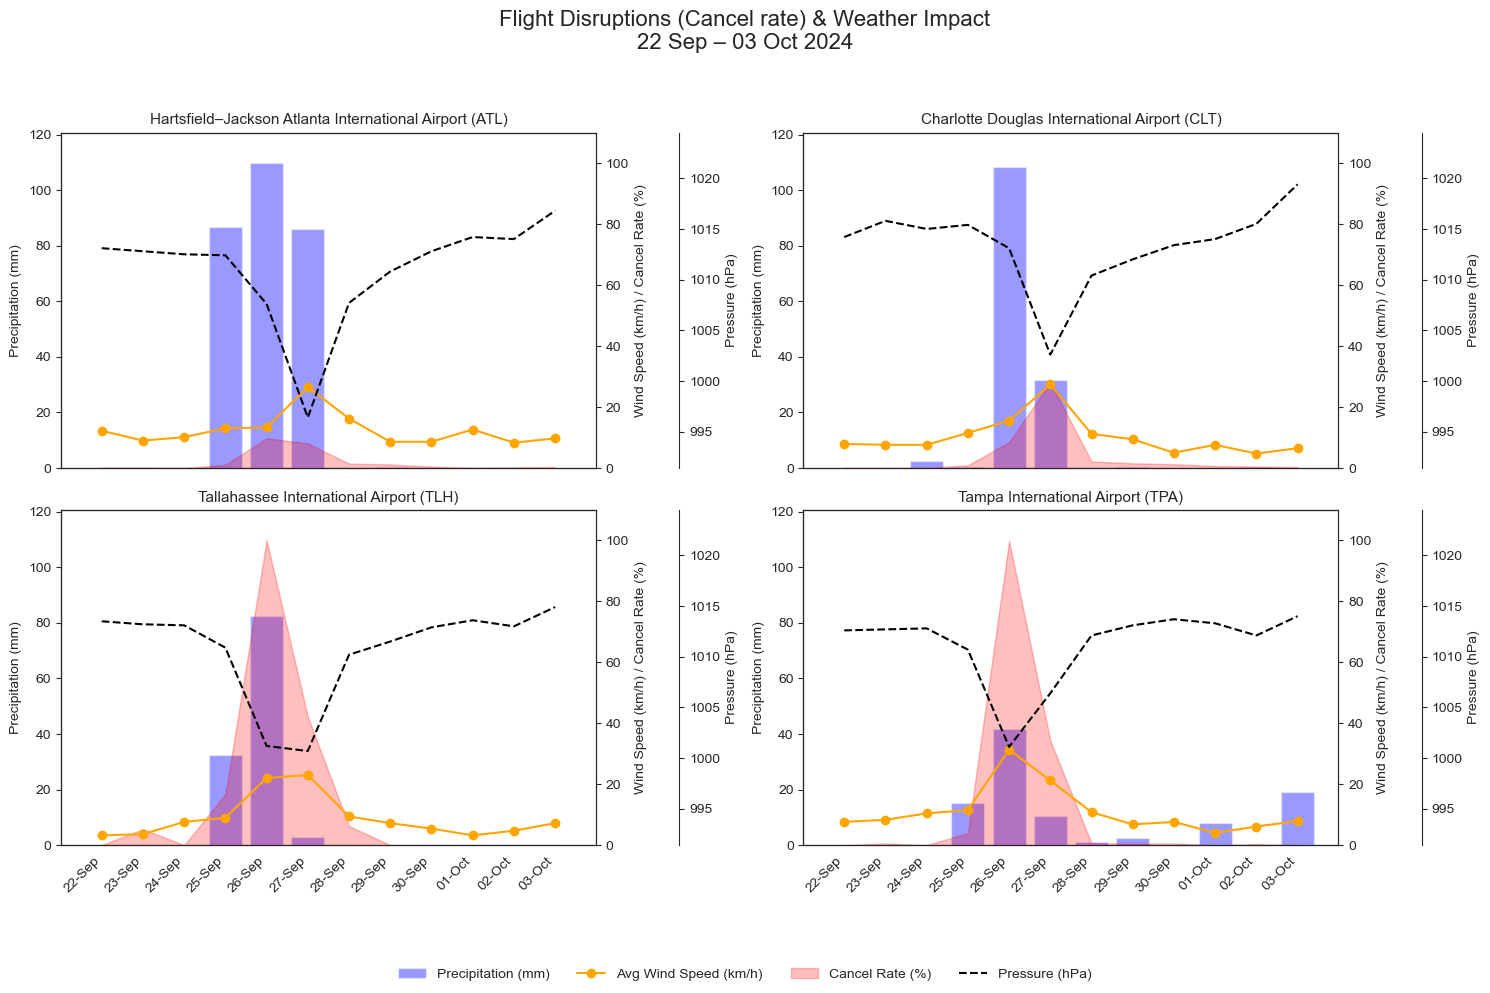

In [36]:
airport_names = {
    'TPA': 'Tampa International Airport',
    'TLH': 'Tallahassee International Airport',
    'ATL': 'Hartsfield–Jackson Atlanta International Airport',
    'CLT': 'Charlotte Douglas International Airport'
}

# если вдруг не datetime
mart_daily_flights_weather['flight_date'] = pd.to_datetime(mart_daily_flights_weather['flight_date'])

airports = mart_daily_flights_weather['airport'].unique()

# --- Global scales ---
delay_max = mart_daily_flights_weather['cancel_rate'].max()
wind_max = mart_daily_flights_weather['avg_wind_speed_kmh'].max()
rain_max = mart_daily_flights_weather['precipitation_mm'].max()
pressure_min = mart_daily_flights_weather['avg_pressure_hpa'].min()
pressure_max = mart_daily_flights_weather['avg_pressure_hpa'].max()

left_ymax = rain_max * 1.1
mid_ymax = max(delay_max, wind_max) * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Flight Disruptions (Cancel rate) & Weather Impact\n22 Sep – 03 Oct 2024",
    fontsize=16,
    y=0.98
)

rain_handle = None
wind_handle = None
delay_handle = None
pressure_handle = None

for ax, airport in zip(axes, airports):
    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    # --- Precipitation (bars, left axis) ---
    rain_handle = ax.bar(
        sub['flight_date'],
        sub['precipitation_mm'],
        alpha=0.4,
        color='blue',
        label="Precipitation (mm)"
    )
    ax.set_ylim(0, left_ymax)
    ax.set_ylabel("Precipitation (mm)")

    # --- Wind + Delay (right axis 1) ---
    ax2 = ax.twinx()

    wind_handle, = ax2.plot(
        sub['flight_date'],
        sub['avg_wind_speed_kmh'],
        color='orange',
        marker='o',
        label="Avg Wind Speed (km/h)"
    )

    # delay as area (not line/bar)
    delay_handle = ax2.fill_between(
        sub['flight_date'],
        sub['cancel_rate'],
        color='red',
        alpha=0.25,
        label="Cancel Rate (%)"
    )

    ax2.set_ylim(0, mid_ymax)
    ax2.set_ylabel("Wind Speed (km/h) / Cancel Rate (%)")

    # --- Pressure (third axis) ---
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    pressure_handle, = ax3.plot(
        sub['flight_date'],
        sub['avg_pressure_hpa'],
        color='black',
        linestyle='--',
        label="Pressure (hPa)"
    )

    ax3.set_ylim(pressure_min * 0.995, pressure_max * 1.005)
    ax3.set_ylabel("Pressure (hPa)")

    ax.set_title(f"{airport_names.get(airport, airport)} ({airport})", fontsize=11)

    ax.grid(False)
    ax2.grid(False)
    ax3.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- One common legend ---
handles = [rain_handle, wind_handle, delay_handle, pressure_handle]
labels = [
    "Precipitation (mm)",
    "Avg Wind Speed (km/h)",
    "Cancel Rate (%)",
    "Pressure (hPa)"
]
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("Cancel_Rate.png", dpi=300, bbox_inches="tight")
plt.show()

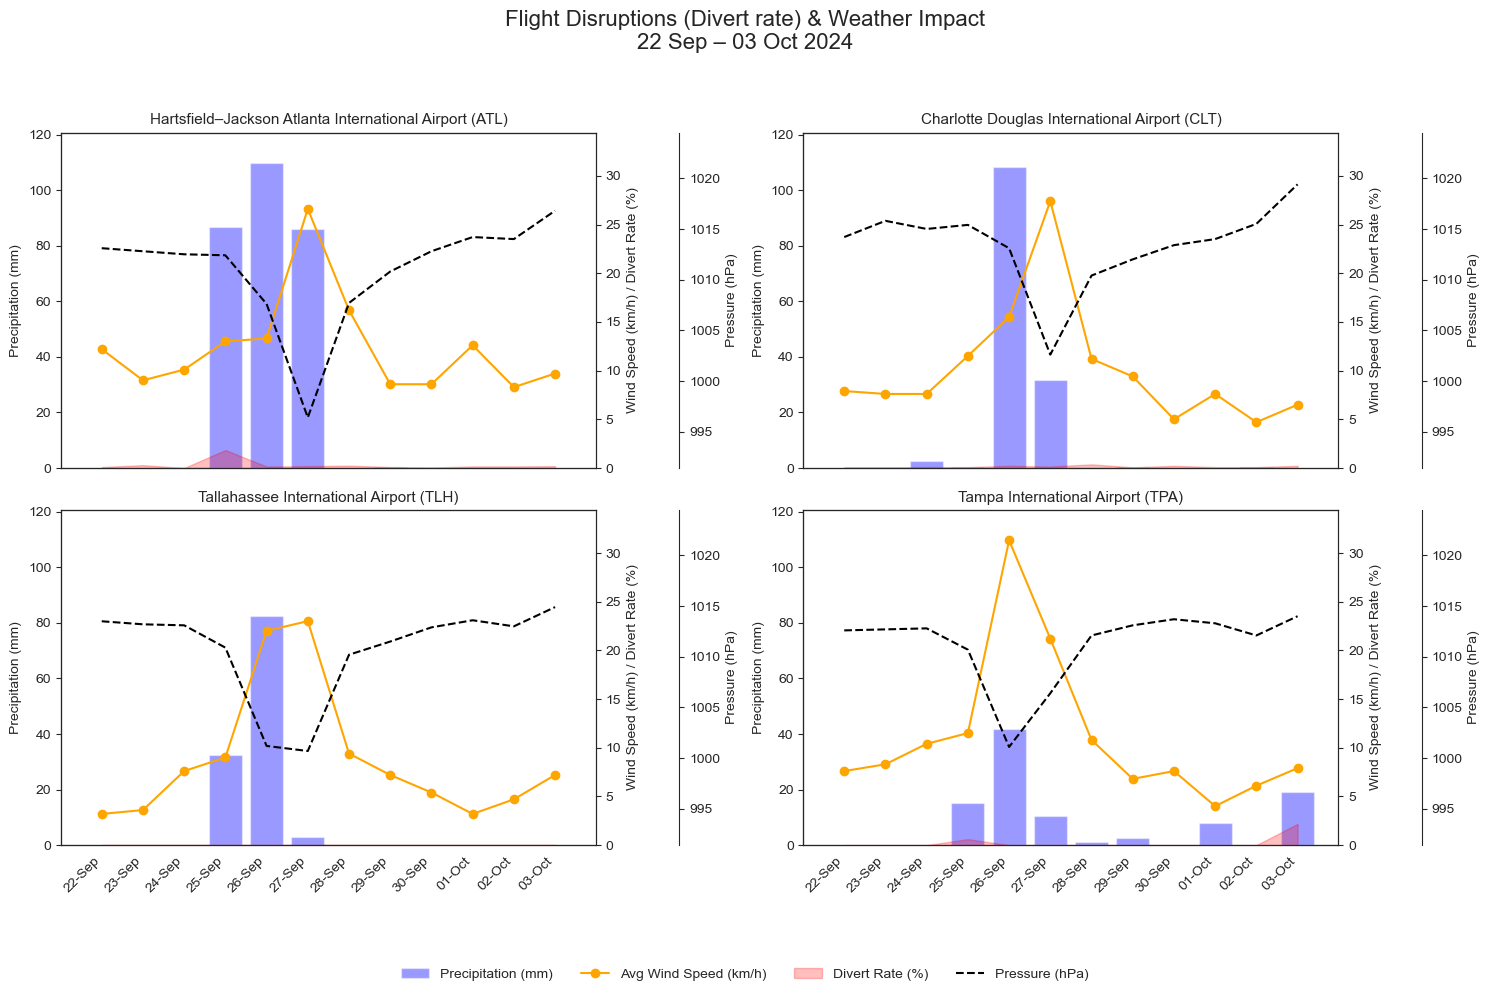

In [37]:
airport_names = {
    'TPA': 'Tampa International Airport',
    'TLH': 'Tallahassee International Airport',
    'ATL': 'Hartsfield–Jackson Atlanta International Airport',
    'CLT': 'Charlotte Douglas International Airport'
}

# если вдруг не datetime
mart_daily_flights_weather['flight_date'] = pd.to_datetime(mart_daily_flights_weather['flight_date'])

airports = mart_daily_flights_weather['airport'].unique()

# --- Global scales ---
delay_max = mart_daily_flights_weather['divert_rate'].max()
wind_max = mart_daily_flights_weather['avg_wind_speed_kmh'].max()
rain_max = mart_daily_flights_weather['precipitation_mm'].max()
pressure_min = mart_daily_flights_weather['avg_pressure_hpa'].min()
pressure_max = mart_daily_flights_weather['avg_pressure_hpa'].max()

left_ymax = rain_max * 1.1
mid_ymax = max(delay_max, wind_max) * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Flight Disruptions (Divert rate) & Weather Impact\n22 Sep – 03 Oct 2024",
    fontsize=16,
    y=0.98
)

rain_handle = None
wind_handle = None
delay_handle = None
pressure_handle = None

for ax, airport in zip(axes, airports):
    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    # --- Precipitation (bars, left axis) ---
    rain_handle = ax.bar(
        sub['flight_date'],
        sub['precipitation_mm'],
        alpha=0.4,
        color='blue',
        label="Precipitation (mm)"
    )
    ax.set_ylim(0, left_ymax)
    ax.set_ylabel("Precipitation (mm)")

    # --- Wind + Delay (right axis 1) ---
    ax2 = ax.twinx()

    wind_handle, = ax2.plot(
        sub['flight_date'],
        sub['avg_wind_speed_kmh'],
        color='orange',
        marker='o',
        label="Avg Wind Speed (km/h)"
    )

    # delay as area (not line/bar)
    delay_handle = ax2.fill_between(
        sub['flight_date'],
        sub['divert_rate'],
        color='red',
        alpha=0.25,
        label="Divert Delay Rate (%)"
    )

    ax2.set_ylim(0, mid_ymax)
    ax2.set_ylabel("Wind Speed (km/h) / Divert Rate (%)")

    # --- Pressure (third axis) ---
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    pressure_handle, = ax3.plot(
        sub['flight_date'],
        sub['avg_pressure_hpa'],
        color='black',
        linestyle='--',
        label="Pressure (hPa)"
    )

    ax3.set_ylim(pressure_min * 0.995, pressure_max * 1.005)
    ax3.set_ylabel("Pressure (hPa)")

    ax.set_title(f"{airport_names.get(airport, airport)} ({airport})", fontsize=11)

    ax.grid(False)
    ax2.grid(False)
    ax3.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- One common legend ---
handles = [rain_handle, wind_handle, delay_handle, pressure_handle]
labels = [
    "Precipitation (mm)",
    "Avg Wind Speed (km/h)",
    "Divert Rate (%)",
    "Pressure (hPa)"
]
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("Divert_Rate.png", dpi=300, bbox_inches="tight")
plt.show()

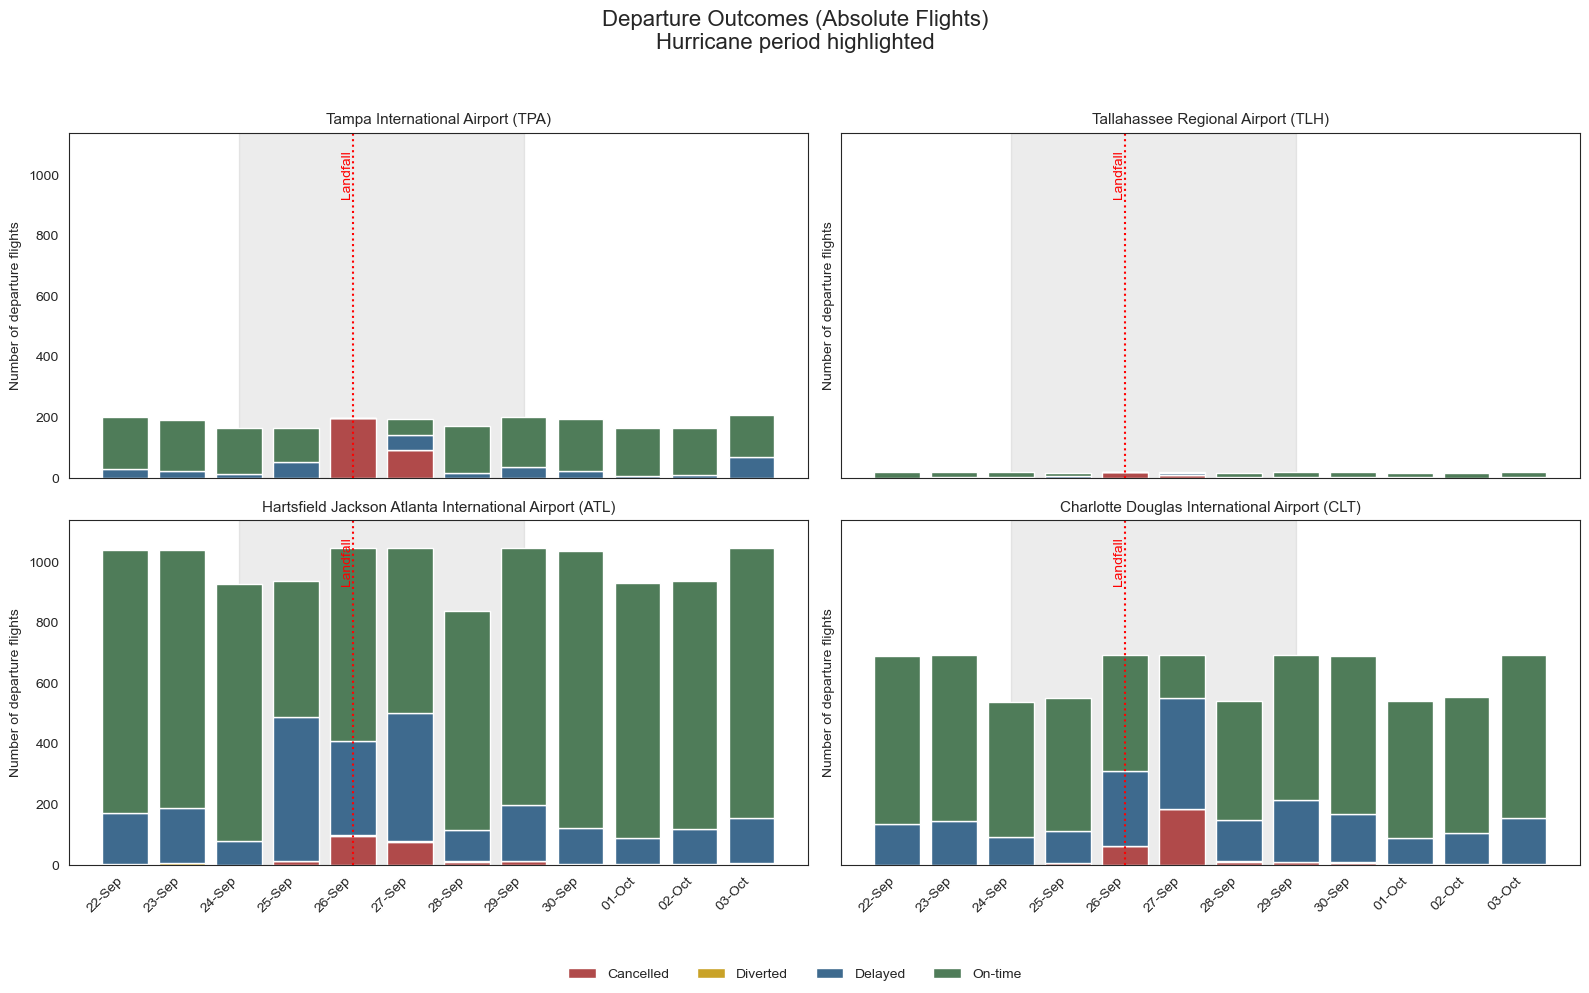

In [41]:
hurricane_start = pd.to_datetime("2024-09-24")
hurricane_end   = pd.to_datetime("2024-09-29")
landfall_day    = pd.to_datetime("2024-09-26")

airports = ['TPA', 'TLH', 'ATL', 'CLT']

mart_daily_flights_weather['flight_date'] = pd.to_datetime(
    mart_daily_flights_weather['flight_date']
)

# --- глобальная шкала ---
max_scheduled = mart_daily_flights_weather['dep_scheduled'].max()
y_max = max_scheduled * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle(
    "Departure Outcomes (Absolute Flights)\nHurricane period highlighted",
    fontsize=16,
    y=0.98
)

for ax, airport in zip(axes, airports):

    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    cancelled = sub['dep_cancelled']
    diverted  = sub['dep_diverted']
    delayed   = sub['dep_delayed_flight']
    on_time   = sub['dep_on_time_flight'] + sub['dep_early_flight']

    # --- Hurricane shading ---
    ax.axvspan(hurricane_start, hurricane_end, color='grey', alpha=0.15, zorder=0)

    bottom = 0
    ax.bar(sub['flight_date'], cancelled, bottom=bottom,
           color='#B04A4A', label='Cancelled')
    bottom = bottom + cancelled

    ax.bar(sub['flight_date'], diverted, bottom=bottom,
           color='#C9A227', label='Diverted')
    bottom = bottom + diverted

    ax.bar(sub['flight_date'], delayed, bottom=bottom,
           color='#3E6A8E', label='Delayed')
    bottom = bottom + delayed

    ax.bar(sub['flight_date'], on_time, bottom=bottom,
           color='#4F7C59', label='On-time')

    # --- Landfall ---
    ax.axvline(landfall_day, color='red', linestyle=':', linewidth=1.5)
    ax.text(
        landfall_day, y_max * 0.95, "Landfall",
        color='red', rotation=90, va='top', ha='right'
    )

    airport_name = sub['airport_name'].iloc[0] if len(sub) else airport
    ax.set_title(f"{airport_name} ({airport})", fontsize=11)

    ax.set_ylim(0, y_max)
    ax.set_ylabel("Number of departure flights")
    ax.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("dep_outcomes_absolute.png", dpi=300, bbox_inches="tight")
plt.show()

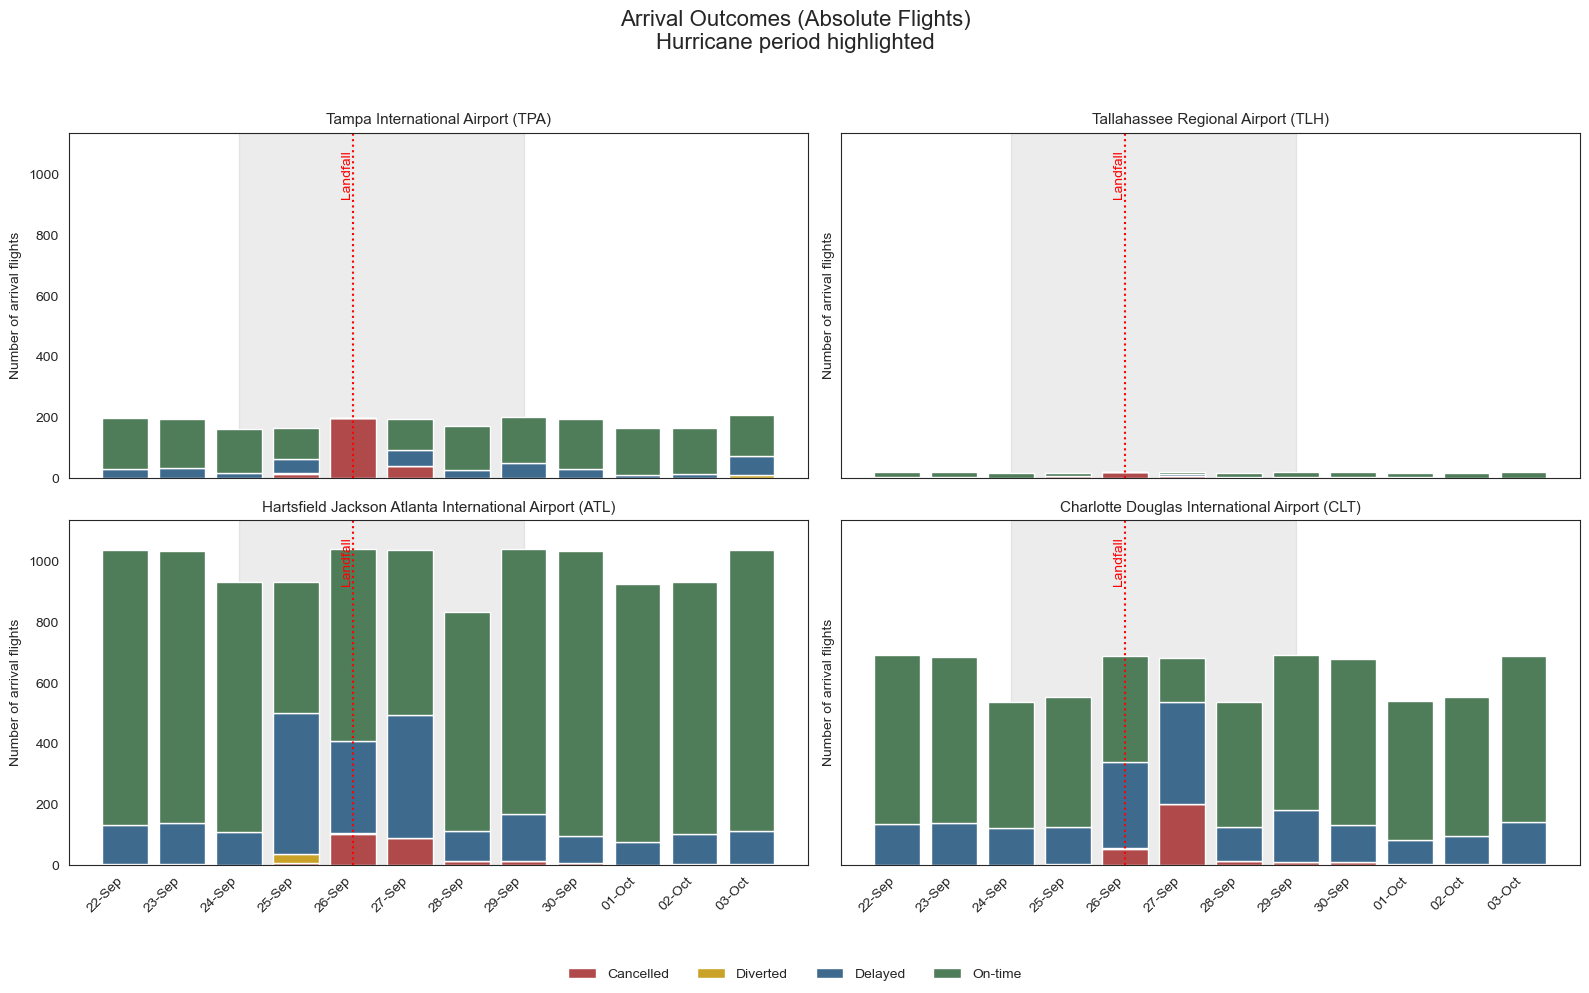

In [42]:
hurricane_start = pd.to_datetime("2024-09-24")
hurricane_end   = pd.to_datetime("2024-09-29")
landfall_day    = pd.to_datetime("2024-09-26")

airports = ['TPA', 'TLH', 'ATL', 'CLT']

mart_daily_flights_weather['flight_date'] = pd.to_datetime(
    mart_daily_flights_weather['flight_date']
)

# --- глобальная шкала (по прилётам) ---
max_scheduled = mart_daily_flights_weather['arr_scheduled'].max()
y_max = max_scheduled * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle(
    "Arrival Outcomes (Absolute Flights)\nHurricane period highlighted",
    fontsize=16,
    y=0.98
)

for ax, airport in zip(axes, airports):

    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    cancelled = sub['arr_cancelled']
    diverted  = sub['arr_diverted']
    delayed   = sub['arr_delayed_flight']
    on_time   = sub['arr_on_time_flight'] + sub['arr_early_flight']

    # --- Hurricane shading ---
    ax.axvspan(hurricane_start, hurricane_end, color='grey', alpha=0.15, zorder=0)

    bottom = 0
    ax.bar(sub['flight_date'], cancelled, bottom=bottom,
           color='#B04A4A', label='Cancelled')
    bottom = bottom + cancelled

    ax.bar(sub['flight_date'], diverted, bottom=bottom,
           color='#C9A227', label='Diverted')
    bottom = bottom + diverted

    ax.bar(sub['flight_date'], delayed, bottom=bottom,
           color='#3E6A8E', label='Delayed')
    bottom = bottom + delayed

    ax.bar(sub['flight_date'], on_time, bottom=bottom,
           color='#4F7C59', label='On-time')

    # --- Landfall ---
    ax.axvline(landfall_day, color='red', linestyle=':', linewidth=1.5)
    ax.text(
        landfall_day, y_max * 0.95, "Landfall",
        color='red', rotation=90, va='top', ha='right'
    )

    airport_name = sub['airport_name'].iloc[0] if len(sub) else airport
    ax.set_title(f"{airport_name} ({airport})", fontsize=11)

    ax.set_ylim(0, y_max)
    ax.set_ylabel("Number of arrival flights")
    ax.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("arr_outcomes_absolute.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
mart_daily_flights_weather.head(2)

,airport,airport_name,city,country,flight_date,dep_scheduled,dep_not_cancelled,dep_cancelled,dep_diverted,dep_early_flight,...,cancel_rate,divert_rate,dep_delayed_rate,arr_delayed_rate,max_temp_c,min_temp_c,precipitation_mm,avg_wind_direction,avg_wind_speed_kmh,avg_pressure_hpa
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-22,1035,1034,1,1,638,...,0.1,0.10,16.43,12.66,36.1,22.2,0.0,0,12.2,1013.1
1,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-23,1030,1029,1,5,618,...,0.1,0.29,17.67,13.18,35.6,22.8,0.0,0,9.0,1012.8


In [52]:
mart_daily_flights_weather.columns

Index(['airport', 'airport_name', 'city', 'country', 'flight_date',
       'dep_scheduled', 'dep_not_cancelled', 'dep_cancelled', 'dep_diverted',
       'dep_early_flight', 'dep_on_time_flight', 'dep_delayed_flight',
       'dep_delayed_sign', 'avg_dep_delay', 'arr_scheduled',
       'arr_not_cancelled', 'arr_cancelled', 'arr_diverted',
       'arr_early_flight', 'arr_on_time_flight', 'arr_delayed_flight',
       'arr_delayed_sign', 'avg_arr_delay', 'total_scheduled',
       'total_cancelled', 'total_diverted', 'total_not_cancelled',
       'cancel_rate', 'divert_rate', 'dep_delayed_rate', 'arr_delayed_rate',
       'max_temp_c', 'min_temp_c', 'precipitation_mm', 'avg_wind_direction',
       'avg_wind_speed_kmh', 'avg_pressure_hpa', 'arr_delay_sign_rate',
       'dep_delay_sign_rate'],
      dtype='object')

In [49]:
mart_daily_flights_weather['arr_delay_sign_rate'] = (mart_daily_flights_weather['arr_delayed_sign']/mart_daily_flights_weather['arr_scheduled']*100).round(2)

mart_daily_flights_weather['dep_delay_sign_rate'] = (mart_daily_flights_weather['dep_delayed_sign']/mart_daily_flights_weather['dep_scheduled']*100).round(2)


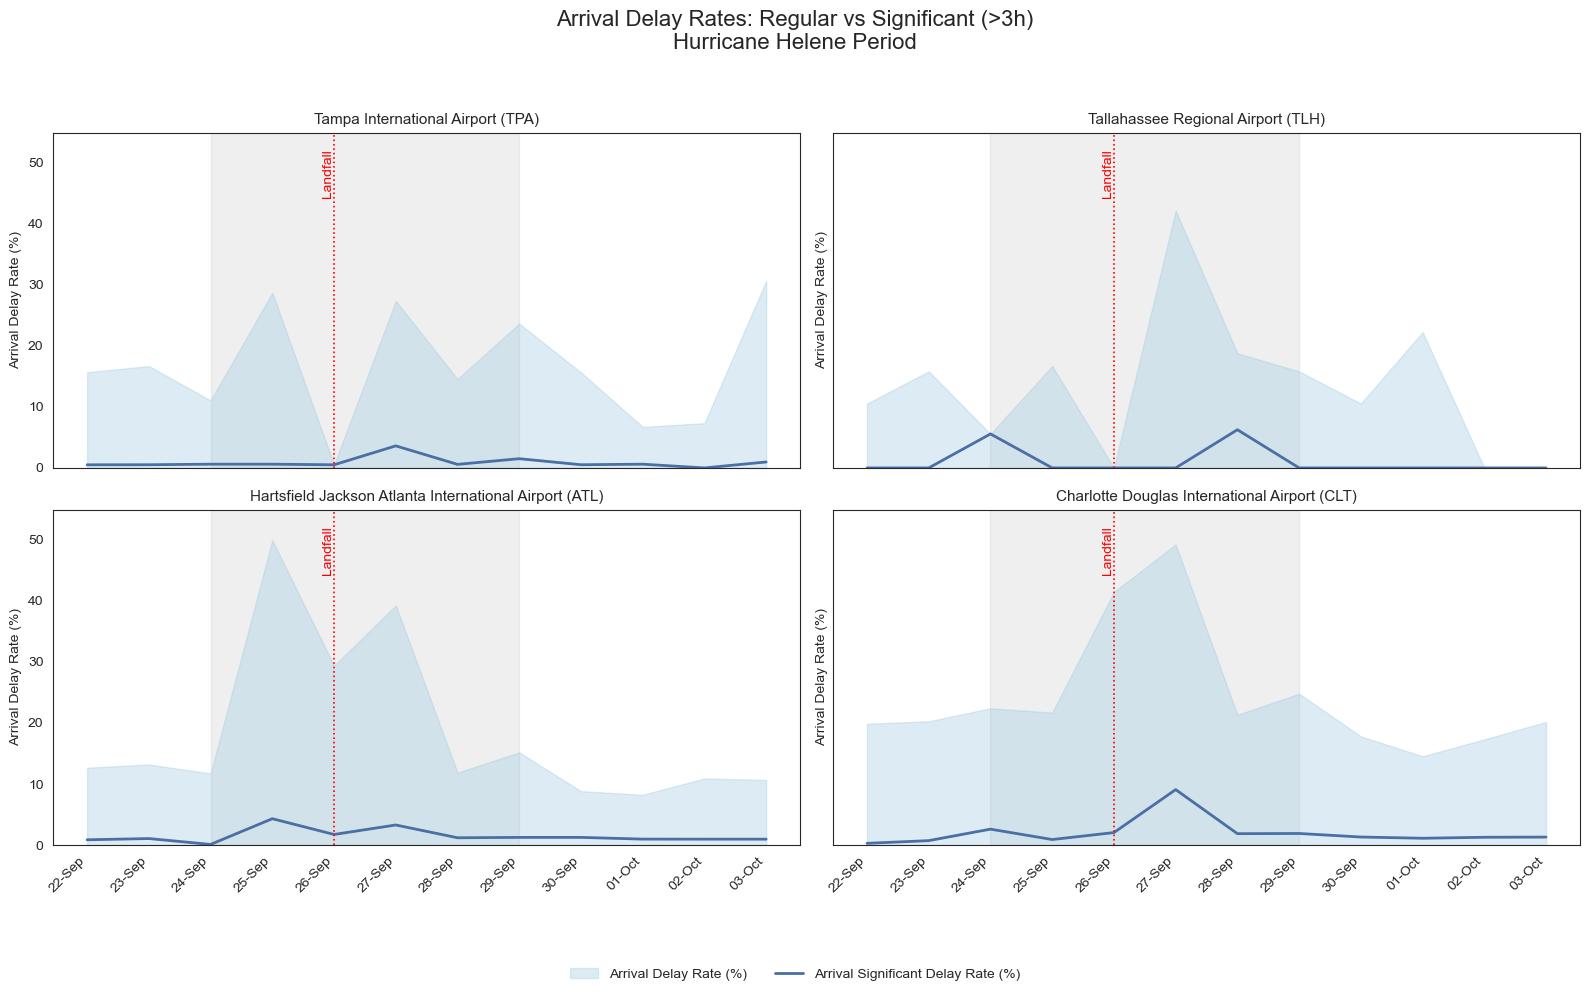

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

hurricane_start = pd.to_datetime("2024-09-24")
hurricane_end   = pd.to_datetime("2024-09-29")
landfall_day    = pd.to_datetime("2024-09-26")

airports = ['TPA', 'TLH', 'ATL', 'CLT']

mart_daily_flights_weather['flight_date'] = pd.to_datetime(
    mart_daily_flights_weather['flight_date']
)

# глобальная шкала только по arrival delay
rate_cols = ['arr_delayed_rate', 'arr_delay_sign_rate']
y_max = mart_daily_flights_weather[rate_cols].max().max() * 1.1

sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle(
    "Arrival Delay Rates: Regular vs Significant (>3h)\nHurricane Helene Period",
    fontsize=16,
    y=0.98
)

for ax, airport in zip(axes, airports):

    sub = mart_daily_flights_weather[
        mart_daily_flights_weather['airport'] == airport
    ].sort_values('flight_date')

    # Hurricane shading
    ax.axvspan(hurricane_start, hurricane_end, color='grey', alpha=0.12)

    # --- Area: regular arrival delay ---
    ax.fill_between(
        sub['flight_date'],
        sub['arr_delayed_rate'],
        color='#9ecae1',
        alpha=0.35,
        label='Arrival Delay Rate (%)'
    )

    # --- Line: significant arrival delay ---
    ax.plot(
        sub['flight_date'],
        sub['arr_delay_sign_rate'],
        color='#4a6fa5',
        linewidth=2,
        label='Arrival Significant Delay Rate (%)'
    )

    # Landfall
    ax.axvline(landfall_day, color='red', linestyle=':', linewidth=1.2)
    ax.text(
        landfall_day,
        y_max * 0.95,
        "Landfall",
        color='red',
        rotation=90,
        va='top',
        ha='right'
    )

    airport_name = sub['airport_name'].iloc[0] if len(sub) else airport
    ax.set_title(f"{airport_name} ({airport})", fontsize=11)

    ax.set_ylim(0, y_max)
    ax.set_ylabel("Arrival Delay Rate (%)")
    ax.grid(False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("arrival_delay_regular_vs_significant.png", dpi=300, bbox_inches="tight")
plt.show()